# NLP - Video Toxicity Analysis
It does not require GPU access to run this notebook.


In [ ]:
!pip install SpeechRecognition pydub
!pip install moviepy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 45.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score ,confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB


import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer, PorterStemmer
import string
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


import speech_recognition as sr
from pydub import AudioSegment
from pydub.silence import split_on_silence

from moviepy.editor import *

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
def expand_contractions(text):
    # Contractions mapping
    contractions = {
        "can't": "cannot",
        "won't": "will not",
        "n't": " not",
        "'ll": " will",
        "'ve": " have",
        "'s": " is",
        "'re": " are",
        "'d": " would",
        "'m": " am"
    }
    # Replace contractions with their expanded forms
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    return text

In [ ]:
def clean_text(text):
    # Lowercasing
    text = text.lower()

#     Expand contractions
    text = expand_contractions(text)

    # Tokenization
    tokens = word_tokenize(text)

    # Removing numerals and special characters
    tokens = [re.sub(r'[^a-zA-Z]', '', word) for word in tokens]

    # Removing punctuation
    tokens = [word for word in tokens if word not in string.punctuation]

    # Removing stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Removing numerals
    tokens = [word for word in tokens if not word.isdigit()]

    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]

    # Join tokens back into a string
    cleaned_text = ' '.join(tokens)

    return cleaned_text

In [ ]:
def make_test_predictions(df, classifier, vect):

    cols_target = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

    df.comment_text = df.comment_text.apply(clean_text)

    X_test = df.comment_text
    X_test_transformed = vect.transform(X_test)

    y_test_pred = classifier.predict_proba(X_test_transformed)
    temp = classifier.predict(X_test_transformed)

    a = np.array(y_test_pred[0])
    sns.barplot(x = cols_target,y =a*100)
    plt.ylim((0,100))

    if np.any(y_test_pred[0] > 0.5):
       plt.title('The comment is Toxic')

    else :
      plt.title('The comment is Non Toxic')

    plt.show()

    label_prob_dict = {}

    for label, probability in zip(cols_target, y_test_pred[0]):
        if probability > 0.5:
            label_prob_dict[label] = probability

    if len(label_prob_dict)>0:
        final_output = "The Audio is Toxic with the below categories and respective intensities - \n"
        for l in label_prob_dict.keys():
            final_output += f"{l}: {round(label_prob_dict[l]*100)} \n"
    else:
        final_output = "The Audio is Non-Toxic"
    print(y_test_pred[0])
    print(label_prob_dict)
    return final_output

In [ ]:
def predict_toxic(text, model, vect):
    comment_text = text
    comment ={'id':[1],'comment_text':[comment_text]}
    comment = pd.DataFrame(comment)
    return make_test_predictions(comment, model, vect)

In [ ]:
def speech_to_text(output_path):
    filename = output_path
    r = sr.Recognizer()
    with sr.AudioFile(filename) as source:
        # listen for the data (load audio to memory)
        audio_data = r.record(source)
        # recognize (convert from speech to text)
        text = r.recognize_google(audio_data)
        print(text)
        return text

In [ ]:
def convert_MOV_mp4_Wav(video):

    # Loading the Video
    vc = VideoFileClip(video)

    # Extract audio from the video
    audio = vc.audio

    # Set the output file path for the .wav file
    output_path = "/content/temp.wav"

    # Write the audio to a .wav file
    audio.write_audiofile(output_path)

    # Close the video file
    vc.close()

    text = speech_to_text(output_path)
    return text

In [ ]:
def convert_mp3_to_wav(mp3_path):

    # Load the audio file
    audio = AudioSegment.from_mp3(mp3_path)

    output_path = "/content/temp.wav"

    # Export as wav
    audio.export(output_path, format="wav")

    text = speech_to_text(output_path)

    return text

In [ ]:
def check_extention(path):

  ext = path.split('.')[1]
  print(ext)

  if ext in ['MOV','mp4']:
    text = convert_MOV_mp4_Wav(path)
  elif ext in ['mp3','mpeg']:
    text = convert_mp3_to_wav(path)

  return text

In [ ]:
# Input Parameters

import pickle

with open('/content/Toxic_lightgbm_model.pkl', 'rb') as fin:
    model = pickle.load(fin)

with open('/content/Toxic_tfidf_vectorizer.pkl', 'rb') as fin:
    vect = pickle.load(fin)

video = "/content/HIM_3.mpeg"

mpeg
if you can't touch your fuck her or make babies with her she's not your woman


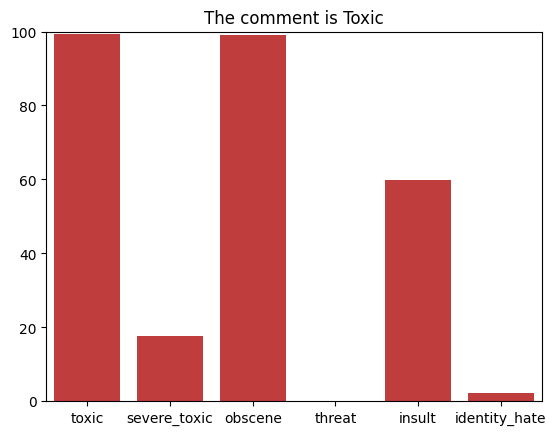

[9.94594092e-01 1.76983258e-01 9.89898827e-01 4.64985168e-05
 5.97606376e-01 2.29450163e-02]
{'toxic': np.float64(0.9945940922411317), 'obscene': np.float64(0.9898988273220873), 'insult': np.float64(0.5976063762497085)}
The Audio is Toxic with the below categories and respective intensities - 
toxic: 99 
obscene: 99 
insult: 60 



In [ ]:
text  = check_extention(video)
output = predict_toxic(text, model, vect)
print(output)

**App - Gradio**

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

def analyze_video(video_file):
    # Function to process the video file and get the text transcript
    text_transcript = check_extention(video_file)

    # Function to analyze toxicity of the text transcript
    sentiment = predict_toxic(text_transcript, model, vect)

    return text_transcript, sentiment


demo = gr.Interface(
    fn=analyze_video,
    inputs=[gr.Video()],
    outputs=[gr.Textbox(label="Video Transcript", lines=5), gr.Textbox(label="Toxicity Analysis", lines=5)]
)

if __name__ == "__main__":
    demo.launch(debug=True)
    # demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d3fd74b01abbe849b0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
